# Slime Mold Sweep — Compute Time by Agent Count

This notebook loads the **low-agent** (500 → 8 000) and **high-agent** (10 000 → 160 000) slime-mold benchmark suites, combines them, and plots the **average pure compute time** for each backend as agent count scales.

Compute time isolates the calculation phase — no setup, rendering, or readback overhead.

In [16]:
import sys, pathlib, importlib

# Ensure src/ is importable regardless of CWD
PROJECT_ROOT = pathlib.Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.constants as C
import src.plot_style as plot_style

# Reload local modules so notebook reruns pick up source edits
importlib.reload(C)
importlib.reload(plot_style)

from src.data_loader import load_all_suites
from src.plot_style import apply_style, save_figure, get_method_color
from src.constants import METHOD_ORDER, METHOD_LABELS


In [17]:
# Choose palette: 0 = Academic, 1 = Teal
PALETTE = 0
apply_style(palette=PALETTE)

## 1 — Load & Combine Data

In [18]:
import pandas as pd

df = load_all_suites(PROJECT_ROOT / "raw-data")
print(f"Loaded {len(df)} runs across suites: {df['suite'].unique().tolist()}")
df.head()

Loaded 118 runs across suites: ['slime-sweep-high-agents', 'slime-sweep-low-agents', 'slime-web-workers-test']


,suite,status,method,renderMode,agentCount,workerCount,wasmExecutionMode,executedFrames,durationMs,avgExecutionMs,...,avgTotalTime,avgCompileTime,compileEvents,frameTime_min,frameTime_max,frameTime_avg,frameTime_stdDev,frameTime_p50,frameTime_p95,frameTime_p99
0,slime-sweep-high-agents,completed,JavaScript,cpu,10000,NaN,NaN,20,743,6.855,...,6.855,0.0,1,5.5,11.5,6.855,1.693657,6.10,10.550,11.310
1,slime-sweep-high-agents,completed,JavaScript,cpu,20000,NaN,NaN,20,807,10.325,...,10.325,0.0,1,9.3,15.8,10.325,1.570629,9.80,13.995,15.439
2,slime-sweep-high-agents,completed,JavaScript,cpu,40000,NaN,NaN,20,1237,17.630,...,17.630,0.0,1,16.6,21.5,17.630,1.292710,17.25,20.930,21.386
3,slime-sweep-high-agents,completed,JavaScript,cpu,80000,NaN,NaN,20,1956,33.360,...,33.360,0.0,1,31.0,44.8,33.360,3.347596,32.40,41.380,44.116
4,slime-sweep-high-agents,completed,JavaScript,cpu,160000,NaN,NaN,20,3429,123.700,...,123.700,0.0,1,118.2,137.2,123.700,5.051534,121.40,136.915,137.143


## 2 — Prepare Plot Data

For each method we pick a single representative per agent count:
- **WebWorkers** → best (lowest compute time) worker count
- **WebAssembly** → best WASM mode (scalar vs. SIMD)
- **WebGPU** → single entry (compute is identical regardless of render mode)
- **JavaScript** → single entry

In [19]:
# Use CPU-render rows (or either render mode — compute is the same)
cpu_df = df[df["renderMode"] == "cpu"].copy()

# WebWorkers: keep best worker count per agent count
ww = cpu_df[cpu_df["method"] == "WebWorkers"]
best_ww = ww.loc[ww.groupby("agentCount")["avgComputeTime"].idxmin()]

# WebAssembly: keep best mode per agent count
wa = cpu_df[cpu_df["method"] == "WebAssembly"]
best_wa = wa.loc[wa.groupby("agentCount")["avgComputeTime"].idxmin()]

# JavaScript (no sub-variants)
js = cpu_df[cpu_df["method"] == "JavaScript"]

# WebGPU — just one row per agent count (compute is identical across render modes)
gpu = cpu_df[cpu_df["method"] == "WebGPU"]

plot_df = pd.concat([js, best_ww, best_wa, gpu], ignore_index=True)
plot_df = plot_df.sort_values("agentCount")

print(f"Plot data: {len(plot_df)} rows")
plot_df[["method", "agentCount", "avgComputeTime"]].head(15)

Plot data: 41 rows


,method,agentCount,avgComputeTime
10,WebWorkers,500,0.345
5,JavaScript,500,0.590
36,WebGPU,500,0.035
21,WebAssembly,500,0.155
6,JavaScript,1000,0.895
22,WebAssembly,1000,0.315
11,WebWorkers,1000,0.510
37,WebGPU,1000,0.025
12,WebWorkers,2000,0.590
38,WebGPU,2000,0.020


## 3 — Plot: Average Compute Time vs. Agent Count

  ✓ Saved outputs/figures/slime_sweep_compute_time.png
  ✓ Saved outputs/figures/slime_sweep_compute_time.pdf


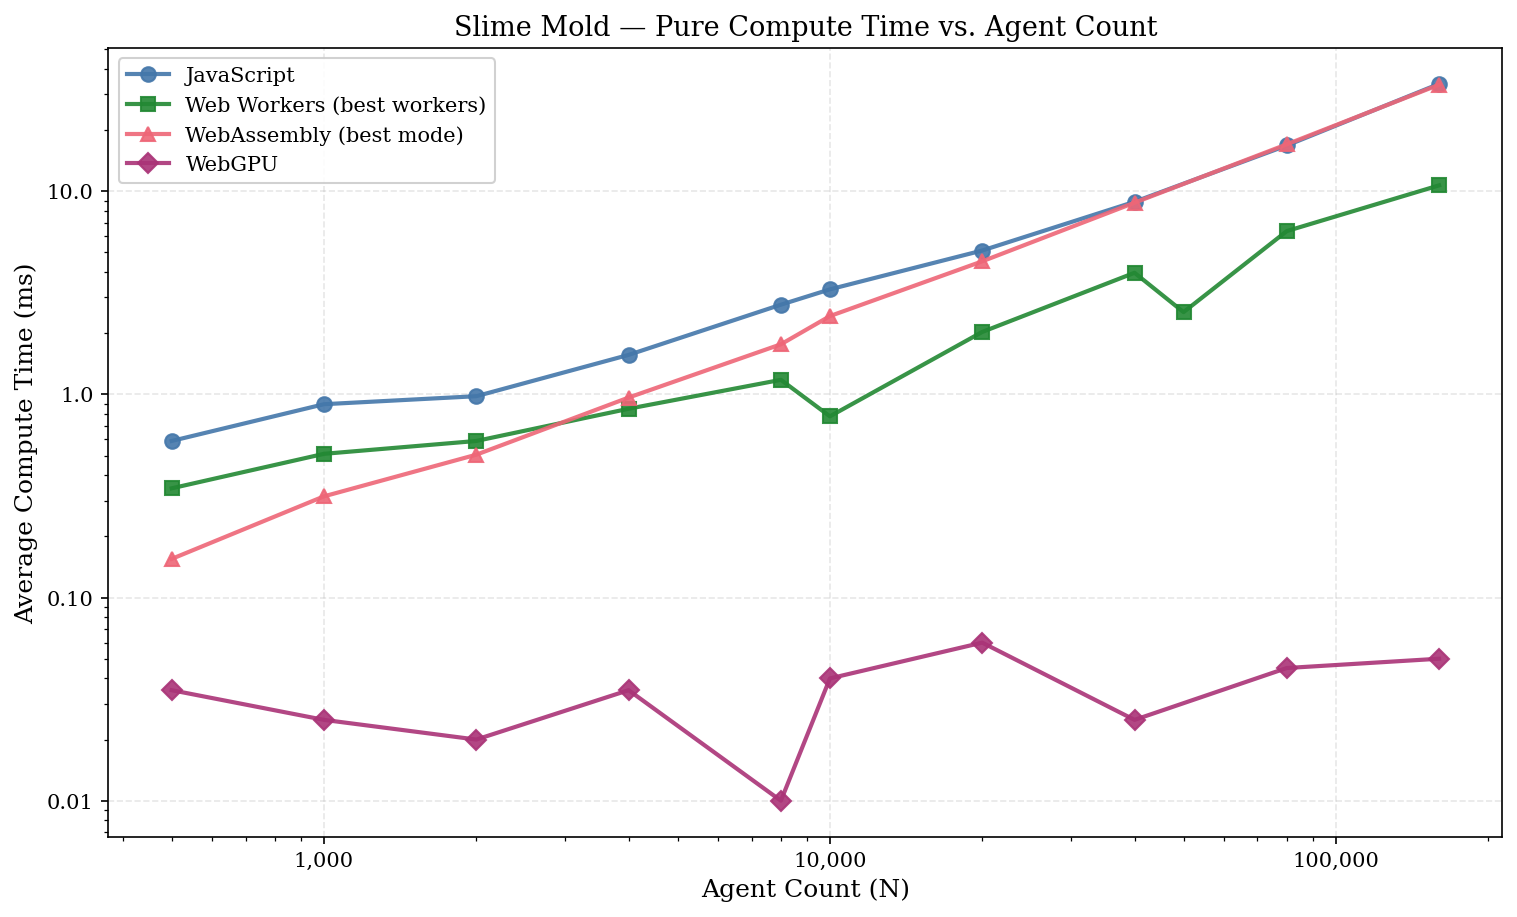

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 6))

markers = {"JavaScript": "o", "WebWorkers": "s", "WebAssembly": "^", "WebGPU": "D"}

for method in METHOD_ORDER:
    subset = plot_df[plot_df["method"] == method].sort_values("agentCount")
    if subset.empty:
        continue
    label = METHOD_LABELS[method]
    if method == "WebWorkers":
        label += " (best workers)"
    elif method == "WebAssembly":
        label += " (best mode)"
    ax.plot(
        subset["agentCount"],
        subset["avgComputeTime"],
        marker=markers.get(method, "o"),
        color=get_method_color(method),
        label=label,
        alpha=0.9,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Agent Count (N)")
ax.set_ylabel("Average Compute Time (ms)")
ax.set_title("Slime Mold — Pure Compute Time vs. Agent Count")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:.2f}" if y < 1 else f"{y:.1f}"))

save_figure(fig, "slime_sweep_compute_time")
plt.show()